# LeetCode #16: 3Sum Closest

https://leetcode.com/problems/3sum-closest/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^3)$ | $O(1)$ |
| **Optimal: Sorting + Two Pointers** ★ | $O(n^2)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Try every possible triplet with three nested loops, tracking whichever sum is closest to target. $O(n^3)$ makes it unusable for large inputs.

### Optimal: Sorting + Two Pointers ★
Sort the array, then for each anchor element use two inward-moving pointers to search the remaining pair. Sorting lets us greedily shrink the gap: if the sum is too low, advance left; too high, retreat right. Early-exit on an exact match.

**Constraints:**
* 3 <= nums.length <= 500
* -1000 <= nums[i] <= 1000
* $-10^4$ <= target <= $10^4$

## Solutions

### C#

In [ ]:
public class Solution {
    public int ThreeSumClosest(int[] nums, int target) {
        Array.Sort(nums);
        int closest = nums[0] + nums[1] + nums[2];

        for (int i = 0; i < nums.Length - 2; i++) {
            int left = i + 1, right = nums.Length - 1;
            while (left < right) {
                int sum = nums[i] + nums[left] + nums[right];
                // Update closest if this sum is nearer to target
                if (Math.Abs(sum - target) < Math.Abs(closest - target))
                    closest = sum;
                if (sum == target) return target;
                else if (sum < target) left++;
                else right--;
            }
        }
        return closest;
    }
}

### Python

In [ ]:
class Solution:
    def threeSumClosest(self, nums: list[int], target: int) -> int:
        nums.sort()
        closest = nums[0] + nums[1] + nums[2]

        for i in range(len(nums) - 2):
            left, right = i + 1, len(nums) - 1
            while left < right:
                total = nums[i] + nums[left] + nums[right]
                # Update closest if this sum is nearer to target
                if abs(total - target) < abs(closest - target):
                    closest = total
                if total == target:
                    return target
                elif total < target:
                    left += 1
                else:
                    right -= 1
        return closest

### Go

In [ ]:
func threeSumClosest(nums []int, target int) int {
    sort.Ints(nums)
    closest := nums[0] + nums[1] + nums[2]

    for i := 0; i < len(nums)-2; i++ {
        left, right := i+1, len(nums)-1
        for left < right {
            sum := nums[i] + nums[left] + nums[right]
            // Update closest if this sum is nearer to target
            if abs(sum-target) < abs(closest-target) {
                closest = sum
            }
            if sum == target {
                return target
            } else if sum < target {
                left++
            } else {
                right--
            }
        }
    }
    return closest
}

func abs(x int) int {
    if x < 0 {
        return -x
    }
    return x
}

### Rust

In [ ]:
impl Solution {
    pub fn three_sum_closest(mut nums: Vec<i32>, target: i32) -> i32 {
        nums.sort_unstable();
        let mut closest = nums[0] + nums[1] + nums[2];

        for i in 0..nums.len() - 2 {
            let (mut left, mut right) = (i + 1, nums.len() - 1);
            while left < right {
                let sum = nums[i] + nums[left] + nums[right];
                // Update closest if this sum is nearer to target
                if (sum - target).abs() < (closest - target).abs() {
                    closest = sum;
                }
                if sum == target {
                    return target;
                } else if sum < target {
                    left += 1;
                } else {
                    right -= 1;
                }
            }
        }
        closest
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `nums = [-1, 2, 1, -4]`, `target = 1`
Sorted: `[-4, -1, 1, 2]`. Anchor $-1$, pointers at $1$ and $2$: sum $= 2$, gap $= 1$. No closer sum found. **Output: 2**

**2. Slightly Complex**
**Input:** `nums = [0, 0, 2, 1, -1]`, `target = 3`
Sorted: `[-1, 0, 0, 1, 2]`. Anchor $0$, left $= 1$, right $= 2$: sum $= 0+1+2 = 3$, exact match. **Output: 3**

**3. Edge Case: Time Factor**
**Input:** `nums = [1, 2, 3, 4, 5]`, `target = 100`
Target is beyond any achievable sum. No early exit — every pair is evaluated before confirming max sum $3+4+5 = 12$. $O(n^2)$ work fully realised. **Output: 12**

**4. Edge Case: Space Factor**
**Input:** `nums = [-2, 0, 0, 2, 2]`, `target = 0`
Sorted: `[-2, 0, 0, 2, 2]`. Anchor $-2$, pointers $0$ and $2$: sum $= 0$, exact match found immediately. No auxiliary storage needed at any point; space is always $O(1)$. **Output: 0**

**5. Almost-Impossible but Plausible**
**Input:** `nums = [-1000, 0, 999, 1000]`, `target = 999`
Sorted. Anchor $-1000$, left $= 999$, right $= 1000$: sum $= -1000+999+1000 = 999$, exact match at extreme boundary values. **Output: 999**

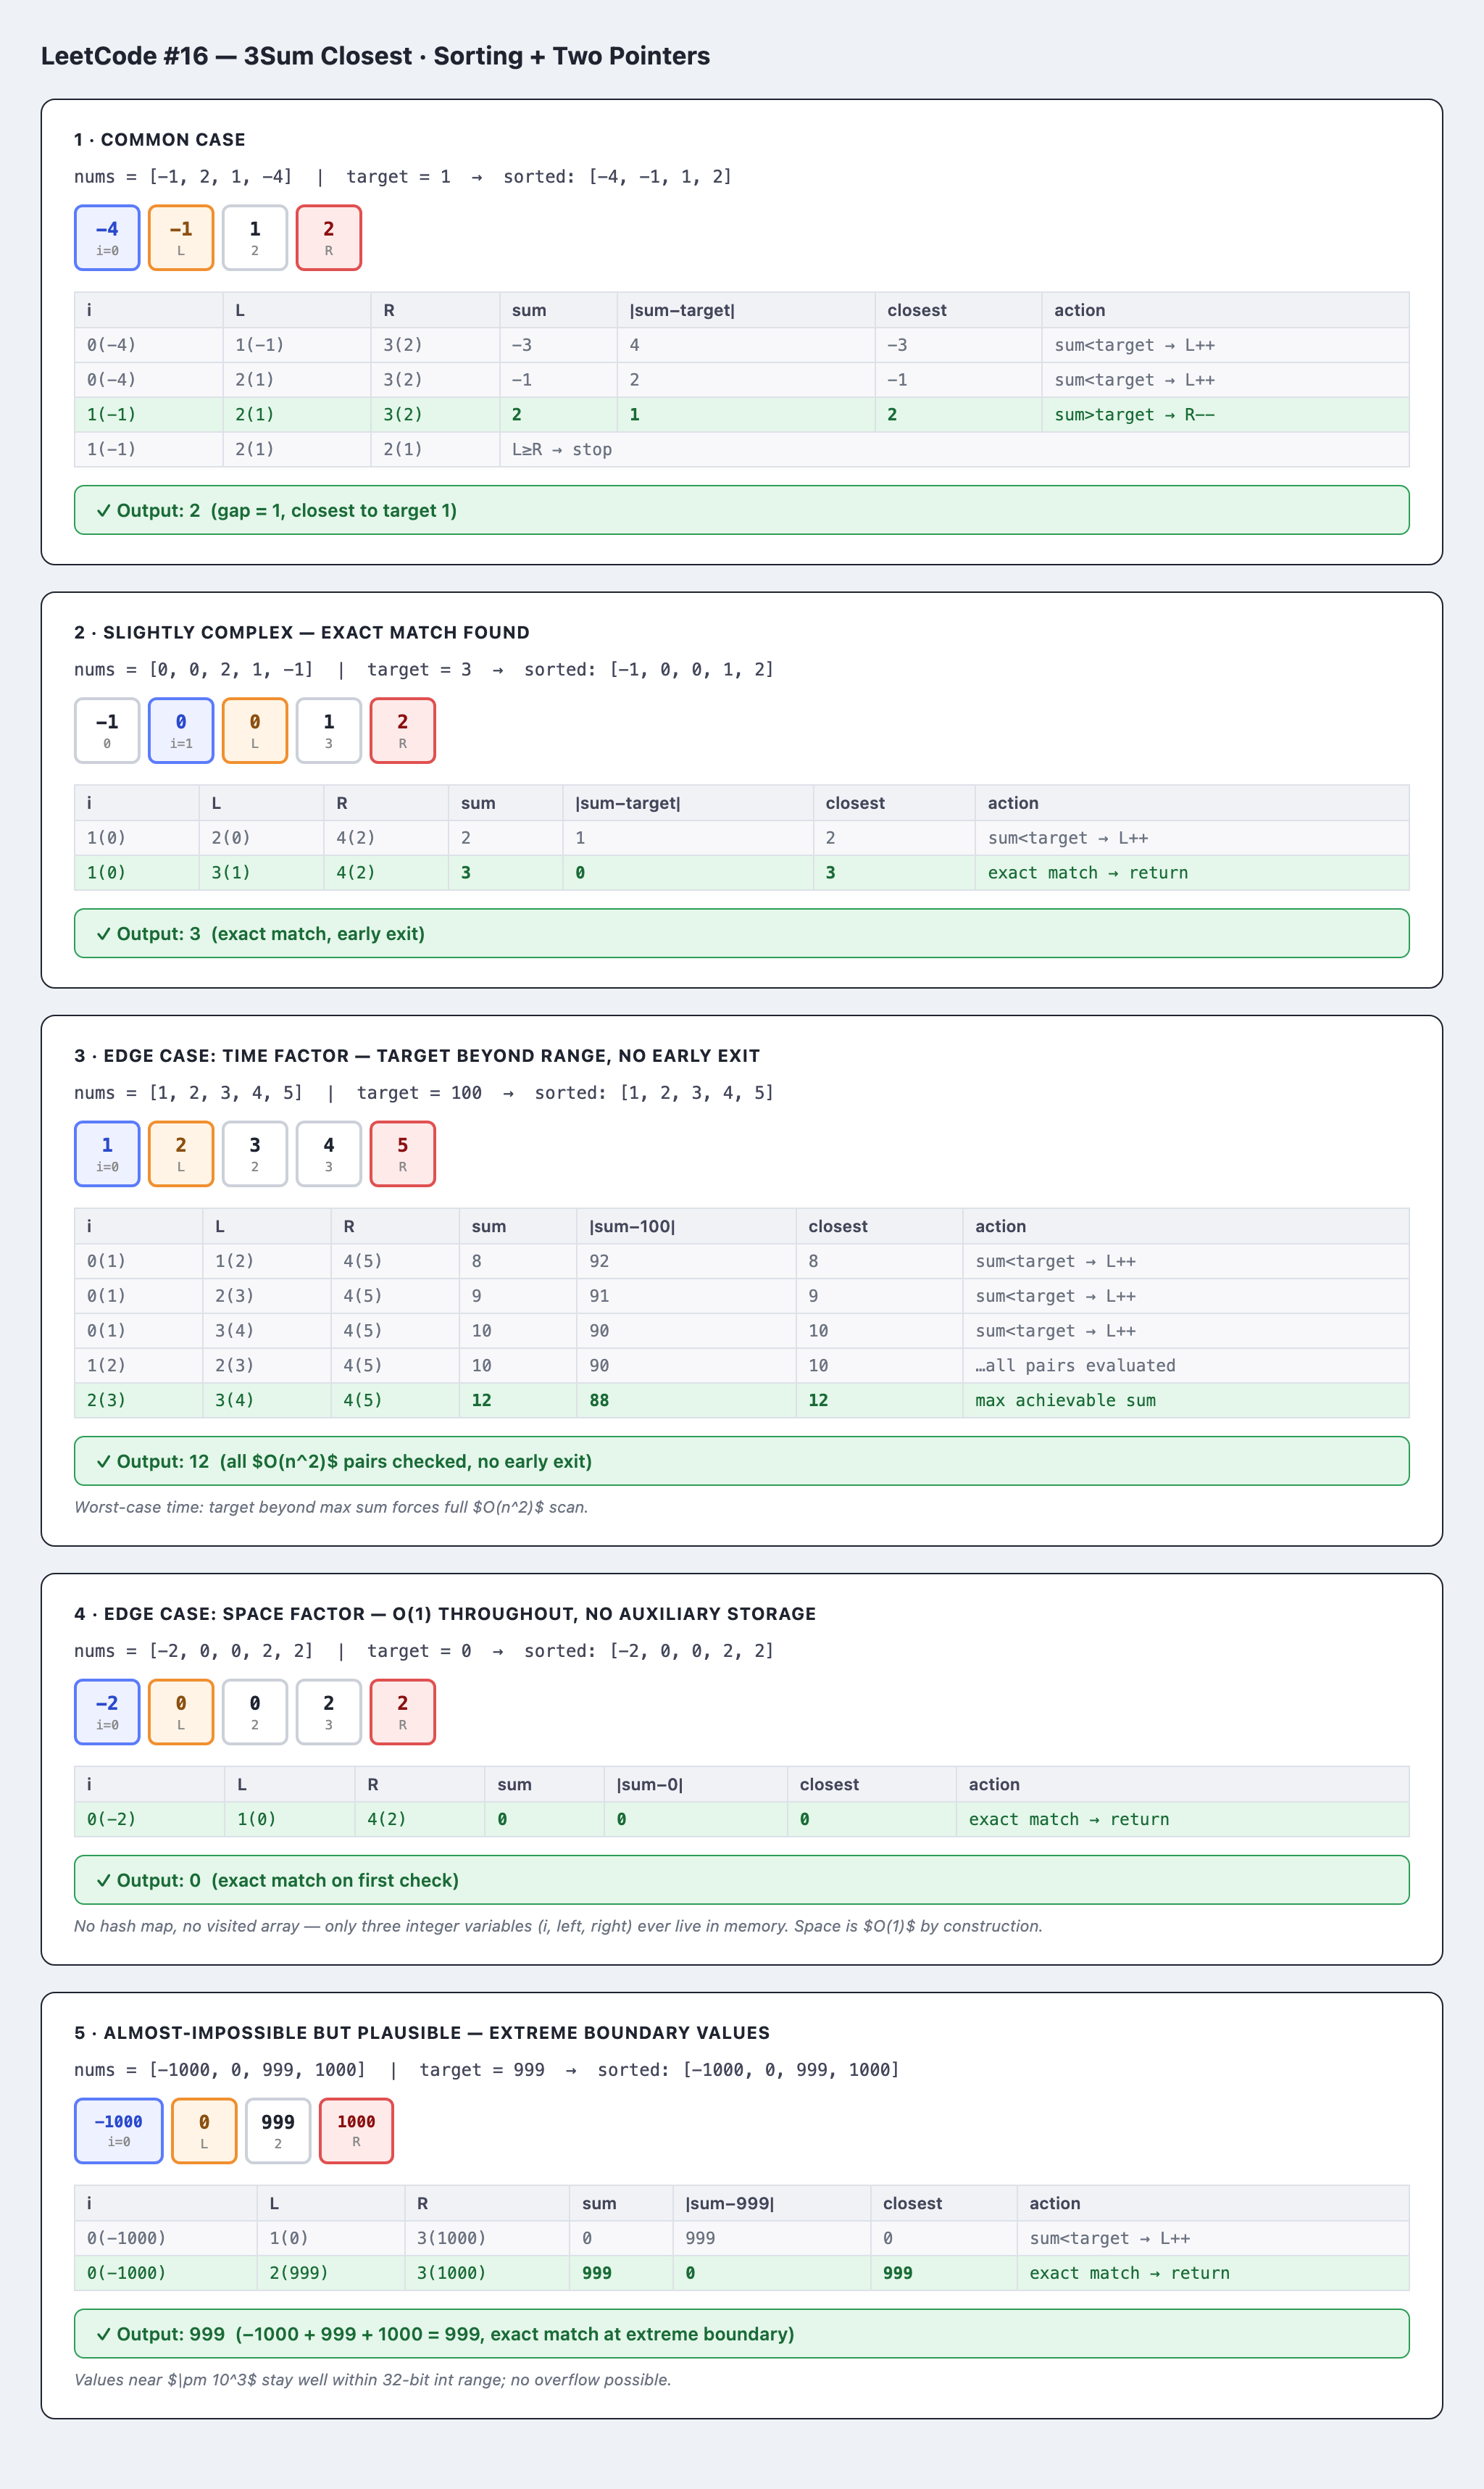